# **Comparative Analysis of Literary Translations in the Odyssey: Zipf's Law in Depth**

This is a comparative Zipf's Law analysis of six translations spanning roughly the last century: 1919–2018. 

## **Road Map**

### I. Libraries, files, and paths

### II. Zipf's Law Analysis

1. All-in, straightforward model  
    a) TTR Computation  
    b) Shapiro-Wilk test to check for normality  
    c) One-wat ANOVA for overall differences  
    d) Pairwise t-test using Bonferroni coprrection  
    c) Meassuring effect size ussing Cohen's d  

2. Adaptive models  
    a) Mixed-Effects model: author fixed effect / book as random effect  
    b) Standardized TTR:   
    c) Moving-average TTR: translation as temporal change  

3. Supplement models  
    a) Lexical Density   
    b) Diachronic analysis  
    c) Semantic fields:  

### IV. Discussing Results
    

## **I. Libraries, files, and paths**

In [106]:
#### Other libraries
import sys
import os

import ast
from collections import Counter

import re
import nltk

In [107]:
#### Pandas set-up
import numpy as np
import pandas as pd

In [108]:
#### Visualization
sys.path.append('/Users/debr/English-Homer') 
import matplotlib.pyplot as plt
import seaborn as sns
import bard_visualization as viz # My Vizualization library

In [109]:
# Import my functions
sys.path.append('/Users/debr/English-Homer/functions') 
import e_nlp as e

In [110]:
#### Cell display options
pd.set_option("display.max_rows", 2000)  # Increase row display
pd.set_option("display.max_colwidth", 200)  # Prevent truncation of long values
pd.set_option("display.precision", 2)  # Display numbers with two decimal places
pd.set_option("display.float_format", "{:.2f}".format)  # Format float numbers
pd.set_option("display.max_columns", None)  # Show all columns
#pd.set_option("display.expand_frame_repr", False)  # Prevent wrapping in DataFrames
pd.set_option("display.width", 1000)  # Prevent wrapping in DataFrames
pd.set_option("colheader_justify", "left")

In [111]:
#### File management
# TO UPDATE
nb_id = "Etymology_Six_Modern"
translators = ["AT_Murray", "Fitzgerald", "Lattimore", "Fagles", "Wilson", "Green"]

# Paths
output_path = f"/Users/debr/English-Homer/{nb_id}/"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

output_path_plots = f"{output_path}/{nb_id}_plots/"
os.makedirs(os.path.dirname(output_path_plots), exist_ok=True)

In [112]:
# Daframe with all the translators
dfs = []

for odyssey in translators:
    filepath = f"/Users/debr/odysseys_en/dataframed/Odyssey_{odyssey}_DataFrame.csv"
    temp_df = pd.read_csv(filepath)  
    dfs.append(temp_df)  # Append it to the list

df = pd.concat(dfs, axis=0, ignore_index=True)

df["text"] = df["text"].apply(ast.literal_eval)
df["tokens"] = df["tokens"].apply(ast.literal_eval)
df['translator'] = pd.Categorical(df['author'])
df["book_num"] = pd.Categorical(df["book_num"])
df = df[['translator', 'book_num', 'text', 'tokens']]
e.check_df(df)

Oh, yeah! No missing values here!

* df columns: Index(['translator', 'book_num', 'text', 'tokens'], dtype='object') 

* Shape: (144, 4) 

* Total memory in MB: 3.488415


In [116]:
df.to_csv(f"/Users/debr/odysseys_en/Odyssey_Six_Modern.csv", index=False)


### **2. The Dictionary



In [8]:
import ety

word = "muse"
etymology = ety.tree(word)
etymology


EtyTree(word='muse')

In [9]:
# Get the etymology of the word "muse" in English
etymology = ety.origins("table")
etymology

[Word(table, Middle English (1100-1500) [enm])]

#### 2. **The translators**

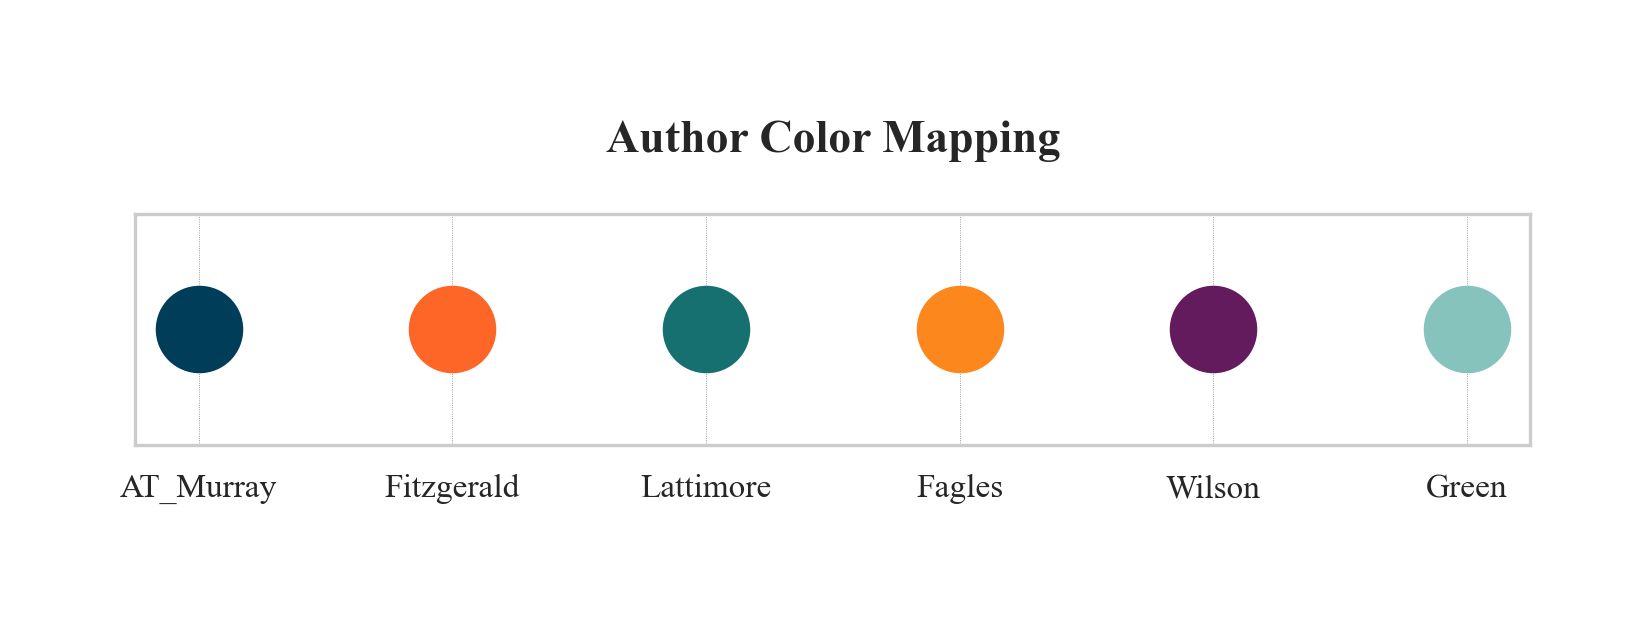

In [10]:
# Color mapping authors
palette = {author: color for author, 
           color in zip(translators, viz.color_palette.values())}

plt.figure(figsize=(6, 1))

for i, (author, color) in enumerate(palette.items()):
    plt.scatter(i, 0, color=color, s=400)

plt.xticks(range(len(palette)), palette.keys(), fontsize=8)
plt.yticks([])
plt.title("Author Color Mapping", fontsize=11)
plt.savefig(f"{output_path_plots}author_color_mapping-{nb_id}.png")
plt.show()

________________________________
## **II. Etymology percentage**

### **What and why:** 




### **Implications for Translation Studies**

**a) 

**b.1) 



### **Implementation** 

1. Getting an etymologycal dictionary
2. Making a dictionary for my data
    a) lemmatize
    b) set of lemmas
    c) pair lemma to it etymology
3. Etymology per author
    a) for lemma in odyssey get etymology
    b) aggregate etymology count per author
    c) plot



The dict: 

Etymological Wordnet 2013-02-08
Gerard de Melo
http://icsi.berkeley.edu/~demelo/etymwn/


== DESCRIPTION ==

The Etymological Wordnet project provides information about how words in different languages 
are etymologically related. The information is mostly mined from the English version of
Wiktionary, but also contains a number of manual additions.


== FORMAT ==

The package includes a Tab-separated values (TSV) file in UTF-8 format with three columns,
providing a word, a relation, and a target word. Words are given with ISO 639-3 codes
(additionally, there are some ISO 639-2 codes prefixed with "p_" to indicate proto-languages).
The most relevant relation is "rel:etymology". To see only etymological relations, run
  grep "rel:etymology" etymwn.tsv | less
on UNIX-based systems.


== CREDITS AND LICENSE ==

Gerard de Melo
http://icsi.berkeley.edy/~demelo/
Based on the contributions of the English Wiktionary community
http://en.wiktionary.org/

License: CC-BY-SA 3.0

In scientific works, please cite:
  Gerard de Melo, Gerhard Weikum. "Towards Universal Multilingual Knowledge Bases".
  In: Principles, Construction, and Applications of Multilingual Wordnets. Proceedings
  of the 5th Global Wordnet Conference (GWC 2010). Narosa Publishing 2010, New Delhi India.

In [11]:
etymologypath = "/Users/debr/odysseys_en/etymwn-20130208/etymwn.tsv"
etymology_df = pd.read_csv(etymologypath, sep="\t", names=["word", "relation", "target_word"], encoding="utf-8")
# for faster look-outs and optimize memory: categorical
etymology_df["relation"] = etymology_df["relation"].astype("category")
etymology_df.sample(10, random_state=402)

,word,relation,target_word
5463534,spa: condicional,rel:has_derived_form,spa: condicionales
467142,eng: albuminization,rel:etymologically_related,eng: toxalbumin
2075742,fra: insulteur,rel:etymologically_related,fra: insulteuse
4897623,lat: torculo,rel:has_derived_form,lat: torculavissent
255143,deu: anfangen,rel:has_derived_form,deu: anfingt
4675182,lat: prodicimini,rel:is_derived_from,lat: prodico
1992445,fra: enflai,rel:is_derived_from,fra: enfler
5773738,spa: sobrecargasen,rel:is_derived_from,spa: sobrecargar
4882662,lat: taedeo,rel:has_derived_form,lat: taedueritis
5357602,spa: aclaraseis,rel:is_derived_from,spa: aclarar


In [12]:
etymology_df.sample(10, random_state=22)

,word,relation,target_word
472465,eng: ambulates,rel:is_derived_from,eng: ambulate
222934,deu: Reise,rel:etymological_origin_of,deu: Reisekader
1980473,fra: embellissement,rel:has_derived_form,fra: embellissements
641094,eng: deadbeat dads,rel:is_derived_from,eng: deadbeat dad
1467823,epo: malvarmiĝanton,rel:is_derived_from,epo: malvarmiĝ
2052983,fra: habillassiez,rel:is_derived_from,fra: habiller
211132,deu: Milch,rel:etymological_origin_of,tpi: milis
636617,eng: cystography,rel:etymological_origin_of,eng: electrocystography
4843023,lat: submoveo,rel:has_derived_form,lat: submovebor
1033364,eng: pinstripe,rel:has_derived_form,eng: pinstripes


In [13]:
relations = [etymology_df['relation'].unique()]
relations

[['rel:etymological_origin_of', 'rel:has_derived_form', 'rel:is_derived_from', 'rel:etymology', 'rel:etymologically_related', 'rel:variant:orthography', 'rel:derived', 'rel:etymologically']
 Categories (8, object): ['rel:derived', 'rel:etymological_origin_of', 'rel:etymologically', 'rel:etymologically_related', 'rel:etymology', 'rel:has_derived_form', 'rel:is_derived_from', 'rel:variant:orthography']]

| Relation                        | Description |
|----------------------------------|------------|
| **rel:etymological_origin_of**   | Indicates that a word is the root or ancestor of another word. Example: Latin *scientia* is the etymological origin of English *science*. |
| **rel:has_derived_form**         | Shows that a word has a derived variant. Example: *happy* has the derived form *happiness*. |
| **rel:is_derived_from**          | Specifies that a word originates from another word. This is the inverse of *rel:etymological_origin_of*. Example: English *science* is derived from Latin *scientia*. |
| **rel:etymology**                | A general relation indicating the etymology of a word without specifying a direction of derivation. |
| **rel:etymologically_related**   | Indicates that two words share a common etymology but are not directly derived from one another. Example: English *hospital* and *host* are etymologically related through Latin *hospes*. |
| **rel:variant:orthography**      | Refers to different spellings of the same word. Example: *color* (American English) vs. *colour* (British English). |
| **rel:derived**                  | A broad category that includes words that evolved from another language but does not specify the exact relationship. |
| **rel:etymologically**           | A general tag used to indicate some form of etymological connection. Often used when the exact type of relation is unclear. |

In [14]:
len(etymology_df)/1000_000

6.031431

In [15]:
e.check_df(etymology_df)

Oh, yeah! No missing values here!

* df columns: Index(['word', 'relation', 'target_word'], dtype='object') 

* Shape: (6031431, 3) 

* Total memory in MB: 922.924706


In [16]:
# Subset of English words
eng_words_df = etymology_df[etymology_df["word"].str.startswith("eng:")]

# Display first few rows
eng_words_df.head(2)

,word,relation,target_word
347600,eng: !OED-->,rel:is_derived_from,eng: old
347601,eng: !OED2-->,rel:is_derived_from,eng: old


In [17]:
target_word = "enm: table"  # Change this to any word you want to match

etymology_root_1 = etymology_df[etymology_df["word"] == target_word]

print(etymology_root_1)

        word        relation                    target_word
1345511  enm: table  rel:etymological_origin_of  eng: table


In [18]:
# Save the DataFrame as a TSV file
#eng_words_df.to_csv('/Users/debr/odysseys_en/ety_engl.tsv', sep='\t', index=False, encoding='utf-8')

In [19]:

#relation_etymology_df = etymology_df[etymology_df["relation"].fillna("").str.match("rel:etymology")]
 # Filter for rows where 'relation' is exactly 'rel:etymology'
#relation_etymology_df = etymology_df[etymology_df["relation"].astype(str).str.match("rel:etymology")]
relation_etymology_df = etymology_df[etymology_df["relation"] == "rel:etymology"]


# Display first few rows
relation_etymology_df.sample(8, random_state=42)

,word,relation,target_word
1727960,fin: räkänokka,rel:etymology,fin: nokka
753310,eng: futureless,rel:etymology,eng: future
842271,eng: inveracity,rel:etymology,eng: in-
804350,eng: homœostasis,rel:etymology,eng: homœ-
1622981,fin: huumekauppias,rel:etymology,fin: huume
404060,eng: Ceylon,rel:etymology,grc: Σελεδίβα
1063714,eng: pritumumab,rel:etymology,eng: -tum-
5429877,spa: cabezota,rel:etymology,spa: -ota


In [20]:
target_word = "eng: ghost"  # Change this to any word you want to match

etymology_root_1 = relation_etymology_df[relation_etymology_df["word"] == target_word]

print("Root 1:", etymology_root_1)

target_word = "enm: gost"  # Change this to any word you want to match

etymology_root_2 = relation_etymology_df[relation_etymology_df["word"] == target_word]

print("\nRoot 2:", etymology_root_2)

target_word = "ang: gast"  # Change this to any word you want to match

etymology_root_3 = relation_etymology_df[relation_etymology_df["word"] == target_word]

print("\nRoot 3:", etymology_root_3)

Root 1:        word        relation       target_word
761941  eng: ghost  rel:etymology  enm: gost 

Root 2:         word       relation       target_word
1342198  enm: gost  rel:etymology  ang: gast 

Root 3: Empty DataFrame
Columns: [word, relation, target_word]
Index: []


In [21]:
def trace_etymology(word, df):
    etymology_chain = [word]  # Store the lineage of words
    
    while True:
        # Find the row where 'word' matches
        etymology_row = df[df["word"] == word]
        
        # If no match is found, stop the loop
        if etymology_row.empty:
            break
        
        # Get the next word in the etymological chain
        next_word = etymology_row["target_word"].values[0]
        
        # Append to the chain and set up for the next iteration
        etymology_chain.append(next_word)
        word = next_word  # Set the next search target

    # Format output sentence
    if len(etymology_chain) > 1:
        etymology_str = ' → '.join(etymology_chain)
        print(f'The word "{etymology_chain[0]}" traces back through: {etymology_str}.')
    else:
        print(f'No etymological root found for "{word}".')

# Example usage
trace_etymology("eng: ghost", relation_etymology_df)

The word "eng: ghost" traces back through: eng: ghost → enm: gost → ang: gast.


In [22]:
trace_etymology("eng: muse", relation_etymology_df)

The word "eng: muse" traces back through: eng: muse → frm: muse → lat: Musa → grc: Μοῦσα.


In [23]:
ety_inquiries = ['muse', 'ghost', 'table', 'sword', 'shield', 'spear', 'battle', 'warrior', 'hero', 'goddess']

for word in ety_inquiries:
    print(f"Word: {word}")
    trace_etymology(f"eng: {word}", relation_etymology_df)
    print("\n")

Word: muse
The word "eng: muse" traces back through: eng: muse → frm: muse → lat: Musa → grc: Μοῦσα.


Word: ghost
The word "eng: ghost" traces back through: eng: ghost → enm: gost → ang: gast.


Word: table
The word "eng: table" traces back through: eng: table → enm: table.


Word: sword
The word "eng: sword" traces back through: eng: sword → enm: sword.


Word: shield
The word "eng: shield" traces back through: eng: shield → ang: scieldan.


Word: spear
The word "eng: spear" traces back through: eng: spear → ang: spere.


Word: battle
The word "eng: battle" traces back through: eng: battle → enm: batel → fro: bataille.


Word: warrior
No etymological root found for "eng: warrior".


Word: hero
No etymological root found for "eng: hero".


Word: goddess
The word "eng: goddess" traces back through: eng: goddess → eng: -ess → fra: -esse → lat: -issa → grc: -ισσα.




In [24]:
target_word = "eng: table"  # Change this to any word you want to match

etymology_root_1 = etymology_df[etymology_df["word"] == target_word]

print(etymology_root_1[24:30])

        word        relation                    target_word             
1221570  eng: table  rel:etymologically_related              eng: tablet
1221571  eng: table  rel:etymologically_related            eng: tabulate
1221572  eng: table               rel:etymology               enm: table
1221573  eng: table        rel:has_derived_form        eng: Cayley table
1221574  eng: table        rel:has_derived_form      eng: billiard table
1221575  eng: table        rel:has_derived_form  eng: bring to the table


In [ ]:
target_word = "enm: table"  # Change this to any word you want to match

etymology_root_1 = etymology_df[etymology_df["word"] == target_word]

print(etymology_root_1)

Empty DataFrame
Columns: [word, relation, target_word]
Index: []


Melo's dictionary is incredible comprehensive yet has a few quirks and pitfalls. 

On the one hand, the word *table* has a clear geanealogy but its truncated in the dictionary. The word table illustrates the limitation our dictionary: the etymological chain eng: table → enm: table doesn't end in the middle English root but goes from the Old English/Germanic *tabal*, deriving from Old High German *zabel*, all the way to the Latin *tabula*. However, the sense of the word rules over its morphology, that "the sense of "piece of furniture consisting of a flat top on legs" is by c. 1300. The usual Latin word for this was mensa (see mensa); Old English writers used *bord* ([etymonline](https://www.etymonline.com/search?q=table)). Nonetheless, chasing the semantic changes of a word is another odyssey in itself. 

On the other hand, *warrior* finds no etymology because it is a derived word from *war*, in turn, has roots in Middle English *werre*. Melo's dictionary does have the information but it is complex to navigate:

1312408  eng: warrior   rel:etymologically_related     eng: war
1311520  eng: war       rel:etymology                  enm: werre
1346286  enm: werre     rel:etymological_origin_of     eng: war

This complexity is also avoided by libraries like **ety**, as exemplified in the image below.


<figure style="text-align: center;">
    <img src="./Etymology_Six_Modern/assets/ety_CLI_warrior.png" alt="Ety_Warrior" width="400"/>
    <figcaption>Etymology of <em>Warrior</em> in CLI ety</figcaption>
</figure>

One of the risks, I guess, is searching in an infinetely recursive loop and finding the specific rules for every instance could prove challenging—not all will break the loop when hitting "rel:etymological_origin_of" or can have multiple repetiontions of relational categories. Let's remember that the dictionary has 6.031431 million entries (and almost a GB in memory). 

Another risk is, as it happens in **ety**, some etymologies chase their suffix, like in the output for CLI `ety goddess -r`:

<figure style="text-align: center;">
    <img src="./Etymology_Six_Modern/assets/ety_CLI_goddess.png" alt="Ety_Goddess" width="400"/>
    <figcaption>Etymology of <em>Goddess</em> in CLI ety</figcaption>
</figure>

The blatant oversight is, however, words like *hero*, which etymology isn't that obscure just ommited. 

In [26]:
etymology_root_1 = etymology_df[etymology_df["word"] == "eng: aback"]
print(etymology_root_1)

       word        relation                    target_word    
449272  eng: aback  rel:etymological_origin_of  eng: abackward
449273  eng: aback        rel:has_derived_form     eng: abacks


In [27]:
etymology_root_1 = etymology_df[etymology_df["word"] == "eng: hero"]
print(etymology_root_1)

       word       relation                    target_word      
795625  eng: hero  rel:etymological_origin_of    eng: anti-hero
795626  eng: hero  rel:etymological_origin_of     eng: antihero
795627  eng: hero  rel:etymological_origin_of    eng: cyberhero
795628  eng: hero  rel:etymological_origin_of      eng: heroess
795629  eng: hero  rel:etymological_origin_of     eng: heroical
795630  eng: hero  rel:etymological_origin_of     eng: herolike
795631  eng: hero  rel:etymological_origin_of     eng: heroship
795632  eng: hero  rel:etymological_origin_of     eng: megahero
795633  eng: hero  rel:etymological_origin_of      eng: nonhero
795634  eng: hero  rel:etymological_origin_of        eng: shero
795635  eng: hero  rel:etymological_origin_of    eng: superhero
795636  eng: hero  rel:etymologically_related       eng: heroic
795637  eng: hero  rel:etymologically_related      eng: heroics
795638  eng: hero  rel:etymologically_related      eng: heroine
795639  eng: hero  rel:etymologically_re

### Creating a etymology lexicon

In [93]:
%time
# 1. Unique words in Odysseys
tokens_set = set().union(*df['tokens'])
tokens_list = list(tokens_set)
tokens_list.sort()
print(len(tokens_list))
print(tokens_list[:11])

CPU times: user 2 μs, sys: 1 μs, total: 3 μs
Wall time: 12.2 μs
16880
['aback', 'abandon', 'abandoned', 'abandoning', 'abased', 'abashed', 'abated', 'abeam', 'abed', 'abetted', 'abetting']


In [66]:
# 2. polishing our function
def get_etymology(word, df):
    etymology_chain = [word]  # Store the lineage of words
    
    while True:
        # Find the row where 'word' matches
        etymology_row = df[df["word"] == word]
        
        # If no match is found, stop the loop
        if etymology_row.empty:
            break
        
        # Get the next word in the etymological chain
        next_word = etymology_row["target_word"].values[-1] # 
        
        # Append to the chain and set up for the next iteration
        etymology_chain.append(next_word)
        word = next_word  # Set the next search target

    return etymology_chain[-1:]


# Example usage
word = "eng: muse"
etymology_chain = get_etymology(word, relation_etymology_df)
print(f'The word "{word}" traces back through: {etymology_chain}.')


The word "eng: muse" traces back through: ['grc: Μοῦσα'].


In [95]:
# 2. polishing our function
def get_etymology(word, df):
    etymology_chain = [word]  # Store the lineage of words
    
    while True:
        # Find the row where 'word' matches
        etymology_row = df[df["word"] == word]
        
        # If no match is found, stop the loop
        if etymology_row.empty:
            break
        
        # Get the next word in the etymological chain
        next_word = etymology_row["target_word"].values[-1] # 
        
        # Append to the chain and set up for the next iteration
        etymology_chain.append(next_word)
        word = next_word  # Set the next search target

    return etymology_chain[-1:]

toy_list = ['spear', 'muse', 'shield', 'abandoning', 'abashed', 'abated', 'abeam', 'warrior', 'goddess', 'hero']
toy_ety = []
for word in toy_list:
    etymology_chain = get_etymology(f"eng: {word}", relation_etymology_df)  # Store result here
    toy_ety.append(etymology_chain)  # Append to the list   
    print(f'The word "{word}" traces back through: {etymology_chain}.')

The word "spear" traces back through: ['ang: spere'].
The word "muse" traces back through: ['grc: Μοῦσα'].
The word "shield" traces back through: ['ang: scield'].
The word "abandoning" traces back through: ['eng: abandoning'].
The word "abashed" traces back through: ['eng: abashed'].
The word "abated" traces back through: ['eng: abated'].
The word "abeam" traces back through: ['ang: byme'].
The word "warrior" traces back through: ['eng: warrior'].
The word "goddess" traces back through: ['eng: god'].
The word "hero" traces back through: ['eng: hero'].


In [96]:
len(toy_list), len(toy_ety)
# 3. Etymology DataFrame
etymology_df = pd.DataFrame(toy_list, columns=["word"])
etymology_df["etymology"] = toy_ety
etymology_df.T

,0,1,2,3,4,5,6,7,8,9
word,spear,muse,shield,abandoning,abashed,abated,abeam,warrior,goddess,hero
etymology,[ang: spere],[grc: Μοῦσα],[ang: scield],[eng: abandoning],[eng: abashed],[eng: abated],[ang: byme],[eng: warrior],[eng: god],[eng: hero]


In [98]:
%time
ety_list = []

for i, word in tokens_list:
    etymology_chain = get_etymology(f"eng: {word}", relation_etymology_df)  # Store result here
    ety_list.append(etymology_chain)  # Append to the list
    
    if i % 500 == 0:  # Print milestone every 500 iterations
        print(f"Processed {i} words...")   


# 3. Etymology DataFrame
etymology_df = pd.DataFrame(tokens_list, columns=["word"])
etymology_df["etymology"] = ety_list
etymology_df.sample()    

CPU times: user 3 μs, sys: 0 ns, total: 3 μs
Wall time: 18.8 μs


ValueError: too many values to unpack (expected 2)

In [100]:
%timeit
# 1. Optimized get_etymology function with cycle detection
def get_etymology(word, df):
    etymology_chain = [word]  # Store the lineage of words
    visited_words = set()  # Track visited words to prevent infinite loops

    while True:
        # Detect cycles
        if word in visited_words:
            print(f"Warning: Cycle detected for '{word}'. Stopping to prevent infinite loop.")
            break  
        visited_words.add(word)

        # Find the row where 'word' matches
        etymology_row = df[df["word"] == word]
        
        # If no match is found, stop the loop
        if etymology_row.empty:
            break
        
        try:
            # Get the next word in the etymological chain
            next_word = etymology_row["target_word"].values[-1]  

            # Append to the chain and set up for the next iteration
            etymology_chain.append(next_word)
            word = next_word  
        except Exception as e:
            print(f"Error processing word '{word}': {e}")
            break  # Exit if there's an issue

    return etymology_chain[-1:]  # Return the last known etymology

# 2. Process all words with milestone prints and error handling
ety_list = []

for i, word in enumerate(tokens_list, start=1):  
    try:
        etymology_chain = get_etymology(f"eng: {word}", relation_etymology_df)
        ety_list.append(etymology_chain)  
    except Exception as e:
        print(f"Skipping '{word}' due to error: {e}")
        ety_list.append([])  # Append empty list for failed lookups

    # Print progress every 500 words
    if i % 500 == 0:  
        print(f"Processed {i} words...")

print("Processing complete!")

# 3. Create the DataFrame
etymology_df = pd.DataFrame({"word": tokens_list, "etymology": ety_list})

# 4. Check a sample of the DataFrame
print(etymology_df.sample())  

Processed 500 words...
Processed 1000 words...
Processed 1500 words...
Processed 2000 words...
Processed 2500 words...
Processed 3000 words...
Processed 3500 words...
Processed 4000 words...
Processed 4500 words...
Processed 5000 words...
Processed 5500 words...
Processed 6000 words...
Processed 6500 words...
Processed 7000 words...
Processed 7500 words...
Processed 8000 words...
Processed 8500 words...
Processed 9000 words...
Processed 9500 words...
Processed 10000 words...
Processed 10500 words...
Processed 11000 words...
Processed 11500 words...
Processed 12000 words...
Processed 12500 words...
Processed 13000 words...
Processed 13500 words...
Processed 14000 words...
Processed 14500 words...
Processed 15000 words...
Processed 15500 words...
Processed 16000 words...
Processed 16500 words...
Processing complete!
     word   etymology    
9776  oared  [eng: oared]


In [103]:
print(etymology_df.sample(20, random_state=42))  

      word            etymology           
12697            seed           [ang: sed]
15296          triple        [eng: triple]
11059       prevailed     [eng: prevailed]
16130         warlord       [eng: warlord]
10477         perhaps       [eng: perhaps]
7098             hits          [eng: hits]
13297         slanted       [eng: slanted]
9742        numbering     [eng: numbering]
16595         wingtip       [eng: wingtip]
2003          bullies       [eng: bullies]
841           astride       [ang: stridan]
8372          legbone       [eng: legbone]
11631  reconciliation  [lat: reconciliare]
1710             bout         [enm: bught]
16008          vistas        [eng: vistas]
59          accepting     [eng: accepting]
14439           suﬀer         [eng: suﬀer]
15416        twilight      [enm: twilight]
14748          terpis        [eng: terpis]
346          alacrity      [eng: alacrity]


In [104]:
e.check_df(etymology_df)

Oh, yeah! No missing values here!

* df columns: Index(['word', 'etymology'], dtype='object') 

* Shape: (16880, 2) 

* Total memory in MB: 2.304614


In [ ]:
# Save the DataFrame as a TSV file
etymology_df.to_csv('/Users/debr/odysseys_en/word_ety_odysseys.tsv', sep='\t', index=False, encoding='utf-8')

In [68]:
toy_list = ['spear', 'muse', 'shield', 'abandoning', 'abashed', 'abated', 'abeam']
ety_dict = {}
for word in toy_list:
    key = word
    value = get_etymology(word, relation_etymology_df)  # Store result here
    # Store the result in the dictionary
    print(f"Key: {key}, Value: {value}")
    # Add the key-value pair to the dictionary"
    ety_dict[key] = value
print(ety_dict)

Key: spear, Value: ['spear']
Key: muse, Value: ['muse']
Key: shield, Value: ['shield']
Key: abandoning, Value: ['abandoning']
Key: abashed, Value: ['abashed']
Key: abated, Value: ['abated']
Key: abeam, Value: ['abeam']
{'spear': ['spear'], 'muse': ['muse'], 'shield': ['shield'], 'abandoning': ['abandoning'], 'abashed': ['abashed'], 'abated': ['abated'], 'abeam': ['abeam']}


In [50]:
toy_list = ['spear', 'muse', 'shield', 'abandoning', 'abashed', 'abated', 'abeam']
def trace_etymology(word, df):
    etymology_chain = [word]  # Store the lineage of words
    
    while True:
        # Find the row where 'word' matches
        etymology_row = df[df["word"] == word]
        
        # If no match is found, stop the loop
        if etymology_row.empty:
            break
        
        # Get the next word in the etymological chain
        next_word = etymology_row["target_word"]
        
        # Append to the chain and set up for the next iteration
        etymology_chain.append(next_word)
        word = next_word  # Set the next search target

    # Return the etymology chain instead of printing
    return etymology_chain

# Example usage to build the dictionary
etym_dictionary = {}

# Loop through each token and get the etymological chain
for token in sorted(toy_list):
    etymology_chain = trace_etymology(token, relation_etymology_df)
    etym_dictionary[token] = etymology_chain

# Optionally print the dictionary to verify the results
print(etym_dictionary)

{'abandoning': ['abandoning'], 'abashed': ['abashed'], 'abated': ['abated'], 'abeam': ['abeam'], 'muse': ['muse'], 'shield': ['shield'], 'spear': ['spear']}


In [42]:
get_etymology('eng: aback', relation_etymology_df)

['eng: aback']

In [31]:
trace_etymology("eng: aback", relation_etymology_df)

['eng: aback']

In [32]:
get_etymology("eng: aback", relation_etymology_df)

['eng: aback']

In [33]:
%%time
# creating a etym_dictionary = {'token': [etymology_chain]}
etym_dictionary = {}

# Loop through each token and get the etymological chain
for token in sorted(tokens_set):
    etymology_chain = get_etymology(token, relation_etymology_df)
    etym_dictionary[token] = etymology_chain 

KeyboardInterrupt: 

In [ ]:
len(etym_dictionary)

16880

In [ ]:
etym_dictionary

{'aback': ['aback'],
 'abandon': ['abandon'],
 'abandoned': ['abandoned'],
 'abandoning': ['abandoning'],
 'abased': ['abased'],
 'abashed': ['abashed'],
 'abated': ['abated'],
 'abeam': ['abeam'],
 'abed': ['abed'],
 'abetted': ['abetted'],
 'abetting': ['abetting'],
 'abhor': ['abhor'],
 'abhorred': ['abhorred'],
 'abide': ['abide'],
 'abides': ['abides'],
 'abiding': ['abiding'],
 'ability': ['ability'],
 'abject': ['abject'],
 'ablaze': ['ablaze'],
 'able': ['able'],
 'ablebodied': ['ablebodied'],
 'ablest': ['ablest'],
 'aboard': ['aboard'],
 'abode': ['abode'],
 'abominable': ['abominable'],
 'abominably': ['abominably'],
 'abominate': ['abominate'],
 'abound': ['abound'],
 'abounding': ['abounding'],
 'abounds': ['abounds'],
 'abreast': ['abreast'],
 'abrim': ['abrim'],
 'abristle': ['abristle'],
 'abroad': ['abroad'],
 'abruptly': ['abruptly'],
 'absence': ['absence'],
 'absences': ['absences'],
 'absent': ['absent'],
 'absolute': ['absolute'],
 'absolutely': ['absolutely'],
 '

In [ ]:
def print_first_x_elements(dictionary, x):
    # Get the first 'x' elements from the dictionary
    first_x_items = list(dictionary.items())[:x]
    
    # Print the elements
    for key, value in first_x_items:
        print(f"{key}: {value}")

print_first_x_elements(etym_dictionary, 23)

aback: ['aback']
abandon: ['abandon']
abandoned: ['abandoned']
abandoning: ['abandoning']
abased: ['abased']
abashed: ['abashed']
abated: ['abated']
abeam: ['abeam']
abed: ['abed']
abetted: ['abetted']
abetting: ['abetting']
abhor: ['abhor']
abhorred: ['abhorred']
abide: ['abide']
abides: ['abides']
abiding: ['abiding']
ability: ['ability']
abject: ['abject']
ablaze: ['ablaze']
able: ['able']
ablebodied: ['ablebodied']
ablest: ['ablest']
aboard: ['aboard']
